# Maximum Likelihood Estimation.

## Libraries and Data.


### Importing the libraries.


In [1]:
from itertools import chain

from anndata import AnnData
from matplotlib import rcParams
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scanpy as sc
import torch
from tqdm import tqdm

from sc_exp_design.data import DataManager, SequentialDataLoader

# defining figure size
FIGSIZE = (3, 3)
rcParams["figure.figsize"] = FIGSIZE


### Reading the data.


In [2]:
PATH = "../../theis/HID01_fcs_concatenated.h5ad"
adata = sc.read_h5ad(PATH)
adata


AnnData object with n_obs × n_vars = 93278696 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'experiment_number', 'experiment_id', 'mtg_[µm]', 'rhflt3l_[ng/ml]', 'gm-csf_[ng/ml]', 'tpo_[ng/ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng/ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng/ml]', 'il3_[ng/ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch'
    var: 'n', 'channel', 'marker', 'PnD', 'PnB', 'PnR', 'PnG', 'PnE', 'signal_type', 'antibody'
    uns: 'meta'

### Subsampling the data.


In [3]:
# optionally subsample the data
KEEP_COPY = True
SUBSAMPLE = True
SUBSAMPLING_DONE = False
SUBSAMPLE_SIZE = 1e-2

if SUBSAMPLE and not SUBSAMPLING_DONE:
    if KEEP_COPY:
        adata_original = adata.copy()
        sc.pp.subsample(adata, SUBSAMPLE_SIZE)
    SUBSAMPLING_DONE = True
adata


AnnData object with n_obs × n_vars = 932786 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'experiment_number', 'experiment_id', 'mtg_[µm]', 'rhflt3l_[ng/ml]', 'gm-csf_[ng/ml]', 'tpo_[ng/ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng/ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng/ml]', 'il3_[ng/ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch'
    var: 'n', 'channel', 'marker', 'PnD', 'PnB', 'PnR', 'PnG', 'PnE', 'signal_type', 'antibody'
    uns: 'meta'

### Applying Tranformation.


In [4]:
cofactor = 10_000
key_arcsin = f"X_arcsinh_cof{cofactor}" 
adata.obsm[key_arcsin] = np.arcsinh(adata.X/cofactor)
adata


AnnData object with n_obs × n_vars = 932786 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'experiment_number', 'experiment_id', 'mtg_[µm]', 'rhflt3l_[ng/ml]', 'gm-csf_[ng/ml]', 'tpo_[ng/ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng/ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng/ml]', 'il3_[ng/ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch'
    var: 'n', 'channel', 'marker', 'PnD', 'PnB', 'PnR', 'PnG', 'PnE', 'signal_type', 'antibody'
    uns: 'meta'
    obsm: 'X_arcsinh_cof10000'

### Initializing DataManager

In [5]:
# data manager
datamanager = DataManager(
    adata,
    sample_rep=key_arcsin
)
data = datamanager.get_data()


### Defining DataLoader.

In [6]:
# data loading
BATCH_SIZE = 128
dataloader = SequentialDataLoader(
    data,
    batch_size=BATCH_SIZE,
)


## MLE of GMM model.

### Defining various setting that we need.

In [7]:
# settings
DIM = adata.X.shape[1]
N_COMPS = 5


### Initializing the Parameters.

In [58]:
weights = torch.nn.Parameter(
    torch.randn(N_COMPS, 1, requires_grad=True, device="cuda")
)
means = torch.nn.Parameter(
    torch.randn(N_COMPS, DIM, requires_grad=True, device="cuda")
)
covs = torch.nn.Parameter(
    torch.randn(N_COMPS, 1, requires_grad=True, device="cuda")
)
means.shape, covs.shape, weights.shape


(torch.Size([5, 21]), torch.Size([5, 1]), torch.Size([5, 1]))

### Optimizing the Parameters.

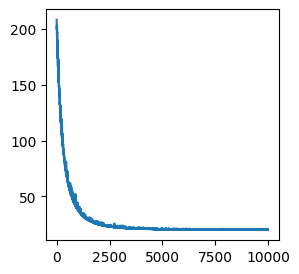

In [ ]:
# defining optimizer
optimizer = torch.optim.Adam(
    [
        weights, means, covs
    ]
    , lr=1e-3
)

# iteration
n_grad_steps = 10_000
n_mc_samples = 50
iterator = range(n_grad_steps)
pbar = tqdm(iterator)

# storing progress
rec_loss_history = np.zeros((n_grad_steps, ))
reg_loss_history = np.zeros((n_grad_steps, ))
loss_history = np.zeros((n_grad_steps, ))
reg_strength = 1e-1


# iterating over gradient steps
for grad_step in iterator:
    # sampling
    states = dataloader.sample()["state_data"]
    states = states.repeat(N_COMPS, 1, 1)

    # handling shapes
    mean = means.unsqueeze(1).repeat(1, BATCH_SIZE, 1)
    cov = covs.unsqueeze(1).repeat(1, BATCH_SIZE, 1)
    weight = weights.unsqueeze(1).repeat(1, BATCH_SIZE, 1)

    # computing activation on weights and covariance
    cov = torch.nn.functional.softplus(cov)**2
    weight = torch.nn.functional.softmax(weight, dim=0)

    # computing likelihood for each component
    ll = (
        (0.5 / cov) * torch.sum((states - mean) ** 2, axis=-1, keepdim=True)
        + 0.5 * torch.log(cov)
        + DIM * 0.5 * torch.log(torch.tensor([2 * np.pi], device=mean.device))
    )[:, :, 0]
    
    weight = weight[:, :, 0]
    loss = ((weight.T)@ll).mean()

    # backprop
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # logging
    pbar.set_description(f"loss: {loss.item()}")
    pbar.update()
    loss_history[grad_step] = loss.item()

# plotting
plt.plot(loss_history)


### Visualizing the learned parameters.

In [ ]:
torch.nn.functional.softmax(weights, dim=0)


tensor([[0.6388],
        [0.1391],
        [0.1302],
        [0.0805],
        [0.0114]], device='cuda:0', grad_fn=<SoftmaxBackward0>)